# Bati Bank — Exploratory Data Analysis

**Goal:** Understand the raw transaction data before any feature engineering.

**Flow:**
1. Load raw data using `loader.py`
2. Clean immediately using `cleaner.py`
3. Explore using `eda.py` visualization functions
4. Write observations after each chart

> Rule: after Cell 2, we never touch `df_raw` again. Everything uses `df_clean`.

In [2]:
# Cell 1 — setup and imports
import sys
import os
import pandas as pd
import numpy as np

os.chdir('..')  # go up one level so Python finds src/

from src.data.loader import load_raw_data, get_summary
from src.data.cleaner import clean
from src.data.eda import (
    plot_missing_values,
    plot_fraud_imbalance,
    plot_transaction_time,
    plot_amount_distribution,
    plot_product_category
)

print('Imports successful')

Imports successful


## 1. Load Raw Data

In [3]:
# Cell 2 — load raw data
df_raw = load_raw_data('data/raw/data.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

INFO: Loading data from: data/raw/data.csv
INFO: Loaded 95662 rows and 16 columns
INFO: All required columns present


Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [4]:
# Cell 3 — inspect column types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult        

In [5]:
# Cell 4 — summary from loader
summary = get_summary(df_raw)
print(f"Rows          : {summary['rows']}")
print(f"Columns       : {summary['columns']}")
print(f"Total missing : {summary['total_missing']}")
print(f"Duplicates    : {summary['duplicate_rows']}")

INFO: Summary: 95662 rows, 0 missing values, 0 duplicates


Rows          : 95662
Columns       : 16
Total missing : 0
Duplicates    : 0


In [6]:
# Cell 5 — missing values per column
missing = {
    col: count
    for col, count in summary['missing_per_column'].items()
    if count > 0
}
if missing:
    for col, count in missing.items():
        pct = round(count / summary['rows'] * 100, 2)
        print(f'  {col}: {count} missing ({pct}%)')
else:
    print('No missing values found')

No missing values found


In [7]:
# Cell 6 — statistics
df_raw.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


### Observations from raw data

1. **Shape:** 95,662 rows, 16 columns
2. **Missing values:** none
3. **Duplicates:** none
4. **TransactionStartTime:** object (string)  must convert to datetime
5. **Amount:** min=-1,000,000 max=9,880,000  extreme outliers
6. **FraudResult mean:** 0.002  only 0.2% fraud  severe class imbalance
7. **CountryCode std:** 0.0  zero variance  will drop

## 2. Clean the Data

In [8]:
# Cell 7 — clean immediately
df_clean = clean(df_raw)
print(f"Raw shape  : {df_raw.shape}")
print(f"Clean shape: {df_clean.shape}")

INFO: Starting cleaning pipeline...
INFO: Converted TransactionStartTime to datetime
INFO: Dropped columns: ['CountryCode']
INFO: Flagged 38189 reversal transactions
INFO: Cleaning complete. Final shape: (95662, 16)


Raw shape  : (95662, 16)
Clean shape: (95662, 16)


In [9]:
# Cell 8 — verify all 3 cleaning steps
print(f"TransactionStartTime dtype : {df_clean['TransactionStartTime'].dtype}")
print(f"CountryCode exists         : {'CountryCode' in df_clean.columns}")
print(f"is_reversal exists         : {'is_reversal' in df_clean.columns}")
print(f"Reversal count             : {df_clean['is_reversal'].sum()}")

# expected:
# TransactionStartTime dtype : datetime64[ns, UTC]
# CountryCode exists         : False
# is_reversal exists         : True
# Reversal count             : 38189

TransactionStartTime dtype : datetime64[ns, UTC]
CountryCode exists         : False
is_reversal exists         : True
Reversal count             : 38189


### Cleaning verification
- TransactionStartTime: object → datetime64 ✓
- CountryCode: dropped ✓
- is_reversal: added (38,189 flagged) ✓



## 3. EDA Visualizations

### 3.1 Missing Values

In [10]:
plot_missing_values(df_clean)

INFO: No missing values to plot — skipping


**Observation:** No missing values skipped gracefully. No imputation needed.

### 3.2 Fraud Class Imbalance

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\10 acadamy\bati-bank-credit\src\data\eda.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\10 acadamy\bati-bank-credit\src\data\eda.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Fraud", "Fraud"])


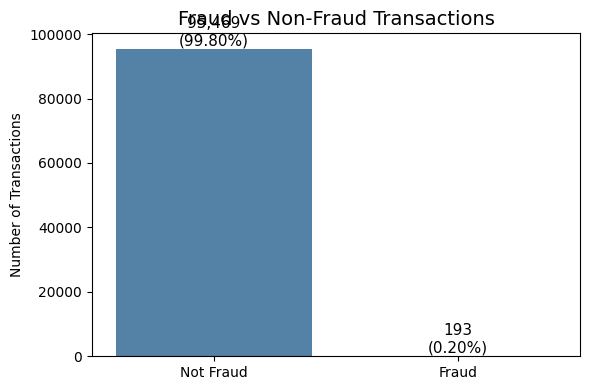

INFO: Saved: outputs/plots/fraud_imbalance.png


In [11]:
plot_fraud_imbalance(df_clean)

**Observation:** 
- Not fraud: 99469 (99.80%) 
- Fraud: 193 (0.20%)  
- **Decision:** ADASYN mandatory  model would predict not-fraud always without it.

### 3.3 Transaction Time Patterns

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


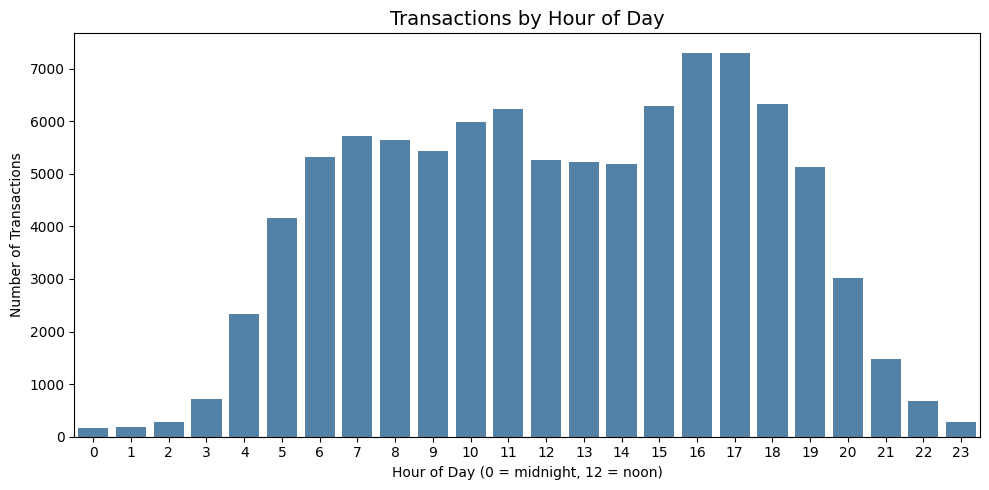

INFO: Saved: outputs/plots/transactions_by_hour.png


In [12]:
plot_transaction_time(df_clean)

**Observation:** 
- Peak hour: 16 and 17 (4pm and 5pm)
- Lowest hour: 0, 1, 2 (midnight to 2am)
- **Decision:** Hour of day will be a useful feature  timing carries behavioral signal.

### 3.4 Amount Distribution

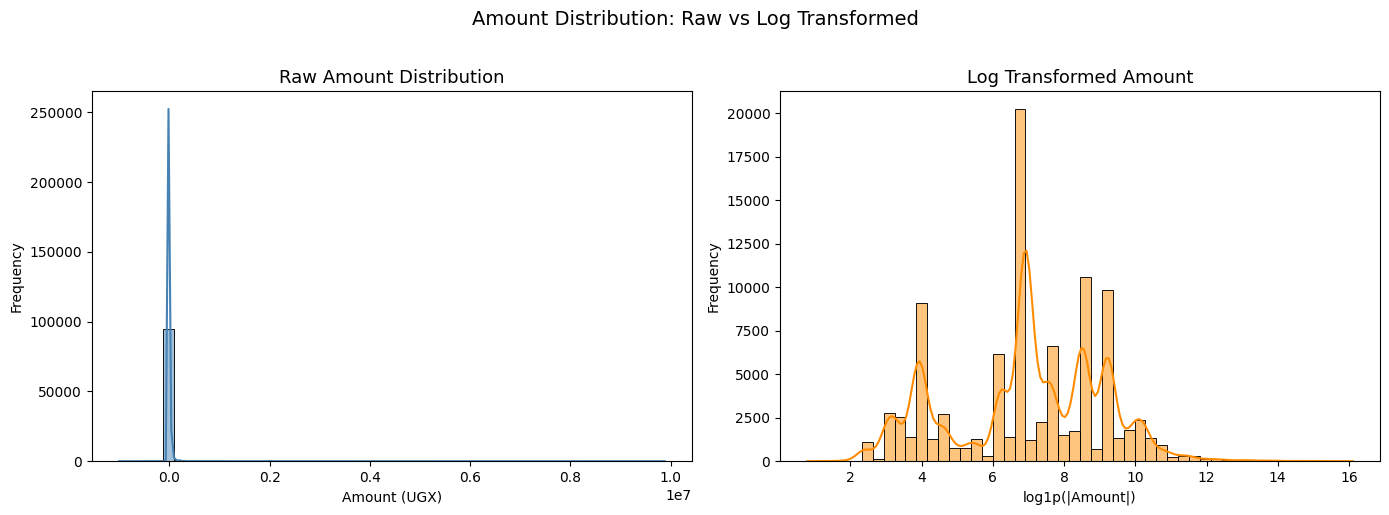

INFO: Saved: outputs/plots/amount_distribution.png


In [13]:
plot_amount_distribution(df_clean)

**Observation:** 
- Raw: unreadable one spike, everything else invisible
- Log transformed: 4 distinct peaks  multimodal distribution
- **Decision:** log transformation confirmed for Amount and Value



### 3.5 Product Category

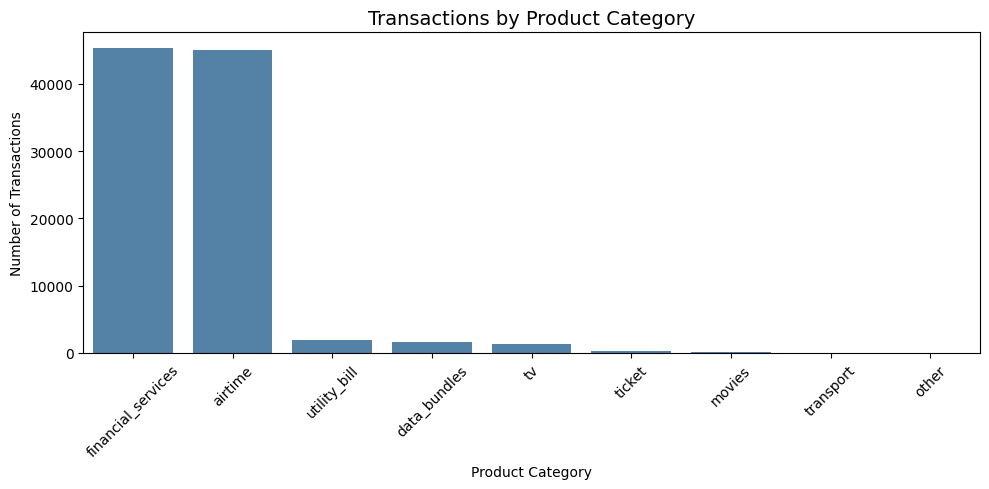

INFO: Saved: outputs/plots/product_category.png


In [14]:
plot_product_category(df_clean)

**Observation:** 
- Most common: financial_services (~45k) and airtime (~45k)
- Least common: Other
- **Decision:** ProductCategory will be encoded as a feature.

## 4. Save Cleaned Data

In [15]:
# Cell 14 — save after EDA is complete
os.makedirs('data/processed', exist_ok=True)
df_clean.to_csv('data/processed/cleaned_data.csv', index=False)
print(f'Saved: data/processed/cleaned_data.csv')
print(f'Shape: {df_clean.shape}')

Saved: data/processed/cleaned_data.csv
Shape: (95662, 16)


## 5. EDA Summary

| Finding | Value | Decision |
|---|---|---|
| Rows | 95,662 | — |
| Missing values | 0 | No imputation needed |
| Duplicates | 0 | No deduplication needed |
| Fraud rate | 0.2% | ADASYN mandatory |
| Reversal transactions | 38,189 (40%) | Keep, flag as feature |
| Amount outliers | max=9,880,000 | Log transformation needed |
| CountryCode | Zero variance | Dropped |
| TransactionStartTime | Was string | Converted to datetime |

**Next step:** `02_features.ipynb` — RFM feature engineering

In [16]:
# fraud rate by product category
fraud_by_category = df_clean.groupby("ProductCategory")["FraudResult"].agg(
    total="count",
    fraud_count="sum"
)
fraud_by_category["fraud_rate_%"] = (
    fraud_by_category["fraud_count"] / fraud_by_category["total"] * 100
).round(2)
fraud_by_category.sort_values("fraud_rate_%", ascending=False)

,total,fraud_count,fraud_rate_%
ProductCategory,,,
transport,25,2,8.00
utility_bill,1920,12,0.62
financial_services,45405,161,0.35
airtime,45027,18,0.04
data_bundles,1613,0,0.00
movies,175,0,0.00
other,2,0,0.00
ticket,216,0,0.00
tv,1279,0,0.00


### Fraud rate by product category

| Category | Total | Fraud | Rate |
|---|---|---|---|
| transport | 25 | 2 | 8.00% ⚠️ small sample |
| utility_bill | 1,920 | 12 | 0.62% |
| financial_services | 45,405 | 161 | 0.35% |
| airtime | 45,027 | 18 | 0.04% |
| data_bundles–tv | 3,285 | 0 | 0.00% |

**Key finding:** 83% of all fraud (161/193) occurs in 
financial_services despite having only 0.35% fraud rate.
Volume drives absolute fraud count, not fraud rate.

**Decision:** encode ProductCategory by fraud risk level
in feature engineering  not just as a plain category label.

In [17]:
print("Last date in dataset :", df_clean["TransactionStartTime"].max())
print("First date in dataset:", df_clean["TransactionStartTime"].min())
print("Unique customers     :", df_clean["CustomerId"].nunique())
print("Unique accounts      :", df_clean["AccountId"].nunique())

Last date in dataset : 2019-02-13 10:01:28+00:00
First date in dataset: 2018-11-15 02:18:49+00:00
Unique customers     : 3742
Unique accounts      : 3633
